In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D, Input, Embedding, GRU, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical

RecursionError: maximum recursion depth exceeded while calling a Python object

In [2]:
df = pd.read_csv("../results/colonoscopy_metadata.csv")

print("Full dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

Full dataset shape: (42126, 7)
Columns: ['source', 'question', 'answer', 'img_id', 'question_type', 'question_norm', 'answer_type']
               source                                           question  \
0  Ulcerative Colitis  Are there any abnormalities in the image? Chec...   
1  Ulcerative Colitis  Are there any anatomical landmarks in the imag...   
2  Ulcerative Colitis  Are there any instruments in the image? Check ...   

               answer                     img_id question_type  \
0  ulcerative colitis  cla820gl0s3nv071u4fgd7xgq        Yes/No   
1                none  cla820gl0s3nv071u4fgd7xgq        Yes/No   
2                none  cla820gl0s3nv071u4fgd7xgq        Yes/No   

                                       question_norm answer_type  
0  are there any abnormalities in the image? chec...       Token  
1  are there any anatomical landmarks in the imag...     None/NA  
2  are there any instruments in the image? check ...     None/NA  


In [3]:
uc_df = df[df['source'].str.contains("colitis", case=False, na=False)].copy()

uc_df['qa_text'] = uc_df['question'].astype(str) + " " + uc_df['answer'].astype(str)

y = uc_df['answer_type']
labels, y = np.unique(y, return_inverse=True)

print("\nUC subset shape:", uc_df.shape)
print("Classes:", labels, "Counts:", np.bincount(y))
print(uc_df[['qa_text','answer_type']].head(3))


UC subset shape: (16890, 8)
Classes: ['List' 'None/NA' 'Numeric' 'Token' 'Yes/No'] Counts: [2098 6639 2980 2190 2983]
                                             qa_text answer_type
0  Are there any abnormalities in the image? Chec...       Token
1  Are there any anatomical landmarks in the imag...     None/NA
2  Are there any instruments in the image? Check ...     None/NA


In [4]:
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(uc_df['qa_text'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (13512, 93)  Test size: (3378, 93)



Classification Report:
              precision    recall  f1-score   support

        List       0.98      1.00      0.99       420
     None/NA       0.99      1.00      1.00      1328
     Numeric       1.00      1.00      1.00       596
       Token       1.00      0.98      0.99       438
      Yes/No       1.00      0.98      0.99       596

    accuracy                           0.99      3378
   macro avg       0.99      0.99      0.99      3378
weighted avg       0.99      0.99      0.99      3378



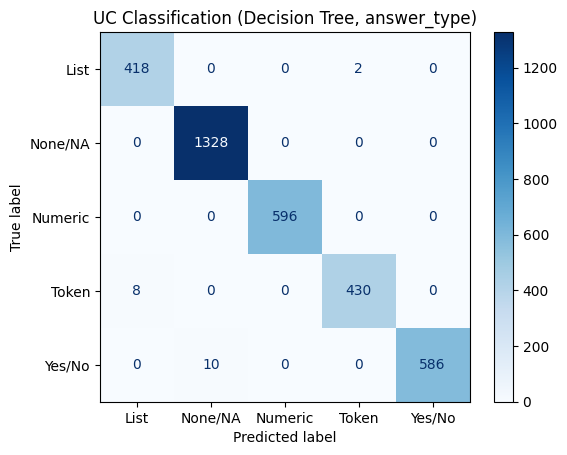

In [5]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=labels))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("UC Classification (Decision Tree, answer_type)")
plt.show()